# 01. Exploratory Data Analysis: Road Damage (RDD2022 China-Drone)

**Computer Vision Group Project, IE School of Science and Technology**

This notebook explores the 300-image, already-annotated RDD2022 China-Drone
subset and converts the Pascal VOC labels into the YOLO format used for
training. Its goals are:

1. Understand the four damage classes and the (strong) class imbalance.
2. Inspect box counts, sizes and shapes, since these drive both the augmentation
   strategy and the severity model.
3. Produce a reproducible train / val / test split (70/20/10, stratified on the
   rarest class) and write `data.yaml`.

Everything downstream (training, severity, demo) depends on the split created at
the end of this notebook.

In [1]:
# === Colab setup: mount Drive and locate the submitted project folder ===
import sys, os, glob, subprocess

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print('Not on Colab, using local paths.')

def find_project_dir():
    pats = ['/content/drive/MyDrive/**/CompVis Group Project',
            '/content/drive/Shareddrives/**/CompVis Group Project',
            '/content/drive/MyDrive/CompVis Group Project']
    for p in pats:
        hits = glob.glob(p, recursive=True)
        if hits:
            return hits[0]
    return os.path.abspath('..')  # local fallback (notebooks/ -> project root)

PROJECT_DIR = find_project_dir()
print('PROJECT_DIR =', PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)


Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/CompVis Group Project


## 0. Reproducibility note: embedded project source

For reproducibility in Google Colab, this notebook writes its helper modules to `/content/src/` at runtime. This keeps the submitted notebook self-contained: the teacher only needs the project folder and the `Data/` directory included with this submission.


In [2]:
# Create the package directory and make it importable.
import os, sys
os.makedirs('/content/src', exist_ok=True)
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

In [3]:
%%writefile /content/src/config.py
"""
Central configuration for the Road Damage Detection project.

Everything that the notebooks and the other modules need to agree on lives here:
the class taxonomy, the colour palette used for plotting, the default training
hyper-parameters and the weights of the rule-based severity model. Keeping these
in one place means a single edit propagates to the EDA, training, inference and
demo code without any duplication.
"""
from __future__ import annotations

import glob
import os
from dataclasses import dataclass, field
from pathlib import Path

# --------------------------------------------------------------------------- #
# Class taxonomy
# --------------------------------------------------------------------------- #
# The four RDD2022 damage categories we keep. The order defines the integer
# class id used in the YOLO label files (D00 -> 0, D10 -> 1, D20 -> 2, D40 -> 3).
CLASS_IDS: dict[str, int] = {
    "D00": 0,  # longitudinal crack  (runs along the driving direction)
    "D10": 1,  # transverse crack    (runs across the road)
    "D20": 2,  # alligator crack     (interconnected / fatigue cracking)
    "D40": 3,  # pothole
}
ID_TO_CLASS: dict[int, str] = {v: k for k, v in CLASS_IDS.items()}

# Human-readable names used in plots, the report and the demo UI.
CLASS_NAMES: dict[str, str] = {
    "D00": "Longitudinal crack",
    "D10": "Transverse crack",
    "D20": "Alligator crack",
    "D40": "Pothole",
}
# Ordered list of short codes, indexed by class id. This is what goes into the
# `names:` field of the Ultralytics data.yaml.
YOLO_NAMES: list[str] = [ID_TO_CLASS[i] for i in range(len(ID_TO_CLASS))]

# Distinct, colour-blind friendly RGB colours per class (for matplotlib / cv2).
CLASS_COLORS: dict[str, tuple[int, int, int]] = {
    "D00": (31, 119, 180),   # blue
    "D10": (255, 127, 14),   # orange
    "D20": (148, 103, 189),  # purple
    "D40": (214, 39, 40),    # red
}

# Severity is drawn with a fixed traffic-light palette so it reads instantly.
SEVERITY_COLORS: dict[str, tuple[int, int, int]] = {
    "Low": (44, 160, 44),     # green
    "Medium": (255, 193, 7),  # amber
    "High": (214, 39, 40),    # red
}
SEVERITY_LEVELS: list[str] = ["Low", "Medium", "High"]

# --------------------------------------------------------------------------- #
# Severity model parameters
# --------------------------------------------------------------------------- #
# The severity score has no ground truth in RDD2022, so it is an engineered,
# fully transparent heuristic. Each class carries a base severity that reflects
# its structural meaning, and the geometry of the box (size / extent) scales it.
# These numbers are documented and justified in report/REPORT.md and can be
# tuned in one place.
SEVERITY_BASE: dict[str, float] = {
    "D00": 0.25,  # a single longitudinal crack is usually minor
    "D10": 0.30,  # transverse cracks slightly worse (water ingress, edges)
    "D20": 0.55,  # alligator cracking signals fatigue / sub-base failure
    "D40": 0.60,  # potholes are an immediate hazard
}
# Thresholds that turn the continuous 0-1 score into a Low/Medium/High label.
SEVERITY_THRESHOLDS: tuple[float, float] = (0.34, 0.67)

# --------------------------------------------------------------------------- #
# Training defaults (reported verbatim in the notebook and the report)
# --------------------------------------------------------------------------- #
@dataclass
class TrainConfig:
    model_scales: list[str] = field(default_factory=lambda: ["n", "s", "m"])
    epochs: int = 100
    patience: int = 20          # early-stopping patience
    imgsz: int = 512            # native resolution of the RDD China-Drone tiles
    batch: int = 16
    optimizer: str = "AdamW"
    lr0: float = 1e-3           # initial learning rate
    lrf: float = 1e-2           # final lr factor (cosine schedule -> lr0*lrf)
    cos_lr: bool = True         # cosine learning-rate scheduler
    weight_decay: float = 5e-4
    warmup_epochs: float = 3.0
    seed: int = 42
    amp: bool = True            # automatic mixed precision
    # Data augmentation (Ultralytics keys). Tuned for small, top-down road tiles:
    # heavy mosaic, modest colour jitter, no vertical flip (gravity matters less
    # from a drone, but we keep it off to stay faithful to capture geometry).
    hsv_h: float = 0.015
    hsv_s: float = 0.5
    hsv_v: float = 0.4
    fliplr: float = 0.5
    flipud: float = 0.0
    mosaic: float = 1.0
    scale: float = 0.5
    translate: float = 0.1
    close_mosaic: int = 10      # disable mosaic for the last N epochs


TRAIN = TrainConfig()

# --------------------------------------------------------------------------- #
# Data-split configuration
# --------------------------------------------------------------------------- #
SPLIT_RATIOS: tuple[float, float, float] = (0.70, 0.20, 0.10)  # train / val / test
SPLIT_SEED: int = 42


# --------------------------------------------------------------------------- #
# Path discovery
# --------------------------------------------------------------------------- #
def find_project_dir() -> Path:
    """Locate the project root both locally and inside Google Colab.

    On Colab the folder lives somewhere under a mounted Drive; we glob for it so
    the notebooks do not hard-code a brittle absolute path. Locally we fall back
    to the parent of this file's `src/` directory.
    """
    patterns = [
        "/content/drive/MyDrive/**/CompVis Group Project",
        "/content/drive/Shareddrives/**/CompVis Group Project",
        "/content/drive/MyDrive/CompVis Group Project",
    ]
    for pattern in patterns:
        hits = glob.glob(pattern, recursive=True)
        if hits:
            return Path(hits[0])
    # Local fallback: src/ -> project root
    return Path(__file__).resolve().parent.parent


def get_paths(project_dir: str | os.PathLike | None = None) -> dict[str, Path]:
    """Return the canonical set of paths used across the project."""
    root = Path(project_dir) if project_dir else find_project_dir()
    return {
        "root": root,
        "raw_images": root / "Data" / "images",
        "raw_annotations": root / "Data" / "annotations" / "xmls",
        "yolo_dataset": root / "outputs" / "yolo_dataset",
        "data_yaml": root / "outputs" / "yolo_dataset" / "data.yaml",
        "models": root / "models",
        "outputs": root / "outputs",
        "figures": root / "figures",
        "report": root / "report",
    }


Writing /content/src/config.py


In [4]:
%%writefile /content/src/data_prep.py
"""
Dataset preparation: Pascal VOC (XML) -> Ultralytics YOLO format.

The RDD2022 China-Drone subset ships as 300 JPEGs plus one Pascal VOC XML per
image. Ultralytics YOLO expects normalised `class cx cy w h` text labels and a
`data.yaml` describing the splits. This module performs that conversion, builds
a reproducible, stratified train/val/test split, and writes the YOLO directory
tree. All functions are pure and seeded so a grader can reproduce the exact
split byte-for-byte.
"""
from __future__ import annotations

import random
import shutil
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

from . import config


@dataclass
class BBox:
    """A single object: class code plus pixel corner coordinates."""
    cls: str
    xmin: float
    ymin: float
    xmax: float
    ymax: float

    @property
    def width(self) -> float:
        return self.xmax - self.xmin

    @property
    def height(self) -> float:
        return self.ymax - self.ymin

    @property
    def area(self) -> float:
        return max(0.0, self.width) * max(0.0, self.height)


@dataclass
class Annotation:
    """All objects in one image plus the image size."""
    filename: str
    width: int
    height: int
    boxes: list[BBox]


# --------------------------------------------------------------------------- #
# Parsing
# --------------------------------------------------------------------------- #
def parse_voc_xml(xml_path: str | Path) -> Annotation:
    """Parse one Pascal VOC XML file into an `Annotation`.

    Objects whose class is not part of `config.CLASS_IDS` are silently skipped,
    and boxes are clamped to the image bounds to guard against the occasional
    off-by-one coordinate found in RDD2022.
    """
    root = ET.parse(xml_path).getroot()
    size = root.find("size")
    width = int(float(size.findtext("width")))
    height = int(float(size.findtext("height")))

    boxes: list[BBox] = []
    for obj in root.findall("object"):
        cls = (obj.findtext("name") or "").strip()
        if cls not in config.CLASS_IDS:
            continue
        bb = obj.find("bndbox")
        xmin = max(0.0, float(bb.findtext("xmin")))
        ymin = max(0.0, float(bb.findtext("ymin")))
        xmax = min(float(width), float(bb.findtext("xmax")))
        ymax = min(float(height), float(bb.findtext("ymax")))
        if xmax <= xmin or ymax <= ymin:
            continue  # degenerate box
        boxes.append(BBox(cls, xmin, ymin, xmax, ymax))
    return Annotation(
        filename=root.findtext("filename") or Path(xml_path).stem + ".jpg",
        width=width,
        height=height,
        boxes=boxes,
    )


def load_all_annotations(annotations_dir: str | Path) -> list[Annotation]:
    """Parse every XML in a directory, sorted for determinism."""
    annotations_dir = Path(annotations_dir)
    xmls = sorted(annotations_dir.glob("*.xml"))
    return [parse_voc_xml(p) for p in xmls]


# --------------------------------------------------------------------------- #
# VOC box -> YOLO line
# --------------------------------------------------------------------------- #
def voc_to_yolo_line(box: BBox, img_w: int, img_h: int) -> str:
    """Convert one VOC box to a normalised YOLO label line."""
    cx = (box.xmin + box.xmax) / 2.0 / img_w
    cy = (box.ymin + box.ymax) / 2.0 / img_h
    w = box.width / img_w
    h = box.height / img_h
    cls_id = config.CLASS_IDS[box.cls]
    return f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"


# --------------------------------------------------------------------------- #
# Stratified split
# --------------------------------------------------------------------------- #
def stratified_split(
    annotations: list[Annotation],
    ratios: tuple[float, float, float] = config.SPLIT_RATIOS,
    seed: int = config.SPLIT_SEED,
) -> dict[str, list[Annotation]]:
    """Split images into train/val/test, balancing the rarest class.

    With only 300 images and a heavy class imbalance (potholes are scarce), a
    naive random split can leave a split with zero potholes. We therefore order
    images by their rarest contained class and deal them round-robin into the
    splits according to the target ratios, which keeps every class present in
    every split while remaining fully deterministic.
    """
    rng = random.Random(seed)

    # Global class frequency -> "rarity" ranking (rarer = smaller count).
    class_freq: Counter[str] = Counter()
    for ann in annotations:
        for b in ann.boxes:
            class_freq[b.cls] += 1
    rarity = {c: i for i, c in enumerate(sorted(class_freq, key=class_freq.get))}

    def sort_key(ann: Annotation) -> tuple[int, float]:
        present = {b.cls for b in ann.boxes}
        rarest = min((rarity[c] for c in present), default=len(rarity))
        return (rarest, rng.random())

    ordered = sorted(annotations, key=sort_key)

    splits: dict[str, list[Annotation]] = {"train": [], "val": [], "test": []}
    names = ["train", "val", "test"]
    # Deal each image to whichever split is furthest below its target share.
    targets = dict(zip(names, ratios))
    for ann in ordered:
        total = sum(len(splits[n]) for n in names) or 1
        deficits = {n: targets[n] - len(splits[n]) / total for n in names}
        chosen = max(names, key=lambda n: deficits[n])
        splits[chosen].append(ann)
    return splits


# --------------------------------------------------------------------------- #
# Writing the YOLO dataset
# --------------------------------------------------------------------------- #
def build_yolo_dataset(
    images_dir: str | Path,
    annotations_dir: str | Path,
    out_dir: str | Path,
    ratios: tuple[float, float, float] = config.SPLIT_RATIOS,
    seed: int = config.SPLIT_SEED,
    copy_images: bool = True,
) -> dict:
    """Convert the whole VOC dataset to a YOLO directory tree + data.yaml.

    Returns a small summary dict (per-split image and box counts) that the EDA
    notebook prints so the split is auditable.
    """
    images_dir = Path(images_dir)
    out_dir = Path(out_dir)

    annotations = load_all_annotations(annotations_dir)
    splits = stratified_split(annotations, ratios, seed)

    summary: dict = {"per_split": {}, "class_per_split": defaultdict(dict)}

    for split_name, anns in splits.items():
        img_out = out_dir / "images" / split_name
        lbl_out = out_dir / "labels" / split_name
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        box_count = 0
        cls_counter: Counter[str] = Counter()
        for ann in anns:
            stem = Path(ann.filename).stem
            src_img = images_dir / ann.filename
            if not src_img.exists():  # tolerate .JPG/.jpg or missing files
                alt = list(images_dir.glob(stem + ".*"))
                if not alt:
                    continue
                src_img = alt[0]
            if copy_images:
                shutil.copy2(src_img, img_out / src_img.name)

            lines = [voc_to_yolo_line(b, ann.width, ann.height) for b in ann.boxes]
            (lbl_out / f"{stem}.txt").write_text("\n".join(lines))
            box_count += len(ann.boxes)
            for b in ann.boxes:
                cls_counter[b.cls] += 1

        summary["per_split"][split_name] = {"images": len(anns), "boxes": box_count}
        summary["class_per_split"][split_name] = dict(cls_counter)

    write_data_yaml(out_dir)
    summary["class_per_split"] = dict(summary["class_per_split"])
    return summary


def write_data_yaml(out_dir: str | Path) -> Path:
    """Write the Ultralytics data.yaml pointing at the three splits."""
    out_dir = Path(out_dir)
    names_block = "\n".join(f"  {i}: {n}" for i, n in enumerate(config.YOLO_NAMES))
    yaml_text = (
        f"# Auto-generated by src/data_prep.py - Road Damage Detection (RDD2022)\n"
        f"path: {out_dir.resolve()}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"test: images/test\n"
        f"nc: {len(config.YOLO_NAMES)}\n"
        f"names:\n{names_block}\n"
    )
    yaml_path = out_dir / "data.yaml"
    yaml_path.write_text(yaml_text)
    return yaml_path


def dataset_class_distribution(annotations: list[Annotation]) -> Counter:
    """Total box count per class across a list of annotations (for EDA)."""
    counter: Counter[str] = Counter()
    for ann in annotations:
        for b in ann.boxes:
            counter[b.cls] += 1
    return counter


Writing /content/src/data_prep.py


In [5]:
%%writefile /content/src/visualization.py
"""
Visualisation helpers: draw detections and severity on images, and a few EDA
plotting utilities shared by the notebooks.

All drawing works on RGB numpy arrays so the functions are equally usable from a
notebook, a script, or the Gradio demo. Nothing here depends on a trained model;
the functions take already-computed detections / severity records.
"""
from __future__ import annotations

from collections import Counter
from pathlib import Path

import cv2
import numpy as np

from . import config


# --------------------------------------------------------------------------- #
# Drawing boxes
# --------------------------------------------------------------------------- #
def _draw_label(img: np.ndarray, text: str, x: int, y: int,
                color: tuple[int, int, int]) -> None:
    """Draw a filled label chip with readable text above a box corner."""
    font, scale, thick = cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1
    (tw, th), base = cv2.getTextSize(text, font, scale, thick)
    y_top = max(0, y - th - base - 4)
    cv2.rectangle(img, (x, y_top), (x + tw + 6, y_top + th + base + 4), color, -1)
    cv2.putText(img, text, (x + 3, y_top + th + 2), font, scale,
                (255, 255, 255), thick, cv2.LINE_AA)


def draw_detections(
    image: np.ndarray,
    severity_records: list[dict],
    color_by: str = "severity",
) -> np.ndarray:
    """Return a copy of `image` with boxes + labels drawn.

    `severity_records` is the list produced by `severity.score_detection`.
    `color_by` is either "severity" (traffic-light) or "class".
    """
    canvas = image.copy()
    for rec in severity_records:
        x1, y1, x2, y2 = (int(v) for v in rec["bbox"])
        if color_by == "severity":
            color = config.SEVERITY_COLORS[rec["severity"]]
        else:
            color = config.CLASS_COLORS.get(rec["class"], (0, 255, 0))
        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
        label = (f"{rec['class']} {rec['confidence']:.2f} "
                 f"| {rec['severity']} {rec['severity_score']:.2f}")
        _draw_label(canvas, label, x1, y1, color)
    return canvas


def severity_banner(image: np.ndarray, condition: dict) -> np.ndarray:
    """Stamp the overall road-condition verdict as a banner across the top."""
    canvas = image.copy()
    level = condition.get("level", "None")
    color = config.SEVERITY_COLORS.get(level, (90, 90, 90))
    text = (f"ROAD CONDITION: {level}  "
            f"(index {condition.get('index', 0):.2f}, "
            f"{condition.get('n_defects', 0)} defects)")
    h, w = canvas.shape[:2]
    cv2.rectangle(canvas, (0, 0), (w, 30), color, -1)
    cv2.putText(canvas, text, (8, 21), cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                (255, 255, 255), 2, cv2.LINE_AA)
    return canvas


# --------------------------------------------------------------------------- #
# EDA plots (matplotlib), imported lazily so cv2-only use stays light
# --------------------------------------------------------------------------- #
def plot_class_distribution(counter: Counter, ax=None, title: str = "Class distribution"):
    import matplotlib.pyplot as plt
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    codes = config.YOLO_NAMES
    counts = [counter.get(c, 0) for c in codes]
    colors = [tuple(v / 255 for v in config.CLASS_COLORS[c]) for c in codes]
    bars = ax.bar([config.CLASS_NAMES[c] for c in codes], counts, color=colors)
    ax.set_title(title)
    ax.set_ylabel("Number of boxes")
    ax.tick_params(axis="x", rotation=20)
    for b, c in zip(bars, counts):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), str(c),
                ha="center", va="bottom", fontsize=9)
    return ax


def plot_boxes_per_image(annotations, ax=None):
    import matplotlib.pyplot as plt
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    counts = [len(a.boxes) for a in annotations]
    ax.hist(counts, bins=range(0, max(counts) + 2), color="#4C78A8",
            edgecolor="white", align="left")
    ax.set_title("Damage instances per image")
    ax.set_xlabel("boxes per image")
    ax.set_ylabel("number of images")
    return ax


def plot_bbox_size_distribution(annotations, ax=None):
    """Scatter of relative box width vs height, reveals tiny/elongated cracks."""
    import matplotlib.pyplot as plt
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    for ann in annotations:
        for b in ann.boxes:
            color = tuple(v / 255 for v in config.CLASS_COLORS[b.cls])
            ax.scatter(b.width / ann.width, b.height / ann.height,
                       s=12, alpha=0.5, color=color)
    ax.set_xlabel("relative width")
    ax.set_ylabel("relative height")
    ax.set_title("Bounding-box shape distribution")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    return ax


def make_gallery(image_paths, annotations_by_name, n: int = 6, cols: int = 3,
                 figsize=(14, 9)):
    """Grid of sample images with their VOC boxes drawn, for the EDA notebook."""
    import matplotlib.pyplot as plt
    paths = list(image_paths)[:n]
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, p in zip(axes, paths):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ann = annotations_by_name.get(Path(p).name)
        if ann:
            for b in ann.boxes:
                color = config.CLASS_COLORS[b.cls]
                cv2.rectangle(img, (int(b.xmin), int(b.ymin)),
                              (int(b.xmax), int(b.ymax)), color, 2)
        ax.imshow(img)
        ax.set_title(Path(p).name, fontsize=8)
    fig.tight_layout()
    return fig


Writing /content/src/visualization.py


**Interpretation.** Most boxes are small and many are highly elongated (the
cracks), so this is primarily a small-object detection problem.

**Modelling implication:** keep the native 512 px resolution, rely on heavy mosaic
augmentation to multiply the number of small objects seen per batch, and avoid
aggressive downscaling. The box elongation (length and thickness) is also the
raw signal that the severity model later turns into engineered features.

**Interpretation.** The classes are strongly imbalanced. The two linear-crack
types dominate (longitudinal 179 and transverse 173 boxes, about 68% of all
defects), while alligator cracking (84) and potholes (78) are each only about
15%.

**Modelling implication:** keep every class present in every split, report per-class
AP, and expect the two rare classes to be the hardest to learn. (In notebook 02
this expectation holds for alligator cracking, but interestingly not for
potholes, which turn out to be the easiest class because they are visually very
distinctive.)

In [6]:
%%writefile /content/src/__init__.py
"""Road Damage Detection, embedded source package (self-contained notebook).

Modules are written to /content/src by the notebook's bootstrap section."""
__version__ = "1.0.0"


Writing /content/src/__init__.py


In [7]:
# Import the freshly written package (clear any stale cached modules).
for _m in [m for m in list(sys.modules) if m == 'src' or m.startswith('src.')]:
    del sys.modules[_m]
from src import config
print('Embedded src package ready, classes:', config.YOLO_NAMES)

In [8]:
%pip install -q seaborn 2>/dev/null  # matplotlib/opencv/numpy/pandas ship with Colab

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from collections import Counter
from src import config, data_prep, visualization
sns.set_theme(style='whitegrid')

paths = config.get_paths(PROJECT_DIR)
IMAGES_DIR = paths['raw_images']
ANN_DIR = paths['raw_annotations']
FIG_DIR = paths['figures']; FIG_DIR.mkdir(parents=True, exist_ok=True)
print('images     :', IMAGES_DIR)
print('annotations:', ANN_DIR)
assert IMAGES_DIR.exists() and ANN_DIR.exists(), 'Check the Data/ folder layout.'

## 1 · Parse all Pascal VOC annotations

Each XML stores the image size and a list of `<object>` boxes. We parse them
into lightweight dataclasses (`src/data_prep.py`) and tabulate the basics.

In [10]:
annotations = data_prep.load_all_annotations(ANN_DIR)
n_imgs = len(annotations)
n_boxes = sum(len(a.boxes) for a in annotations)
n_empty = sum(1 for a in annotations if not a.boxes)
sizes = {(a.width, a.height) for a in annotations}
print(f'Images parsed         : {n_imgs}')
print(f'Total damage instances: {n_boxes}')
print(f'Avg boxes / image     : {n_boxes / n_imgs:.2f}')
print(f'Background (no-box) img: {n_empty}')
print(f'Distinct image sizes  : {sizes}')

metric,value
Images,300
Annotation files,300
Annotated defects,514
Average defects per image,1.71
Image size,512 x 512


**Interpretation.** The dataset is small and clean: 300 images, 514 annotated defects (about 1.71 per image), every image is 512x512, and there are no background-only images. With so few instances, transfer learning from COCO-pretrained weights is essential, and per-class metrics are more informative than the overall mean alone.


## 2 · Class distribution

Road-damage datasets are notoriously imbalanced. The chart below shows how
many boxes each class has, note how scarce potholes (`D40`) typically are
relative to cracks. This imbalance is the single most important fact for
interpreting per-class metrics later.

class,boxes,share
D00,179,0.348
D10,173,0.337
D20,84,0.163
D40,78,0.152


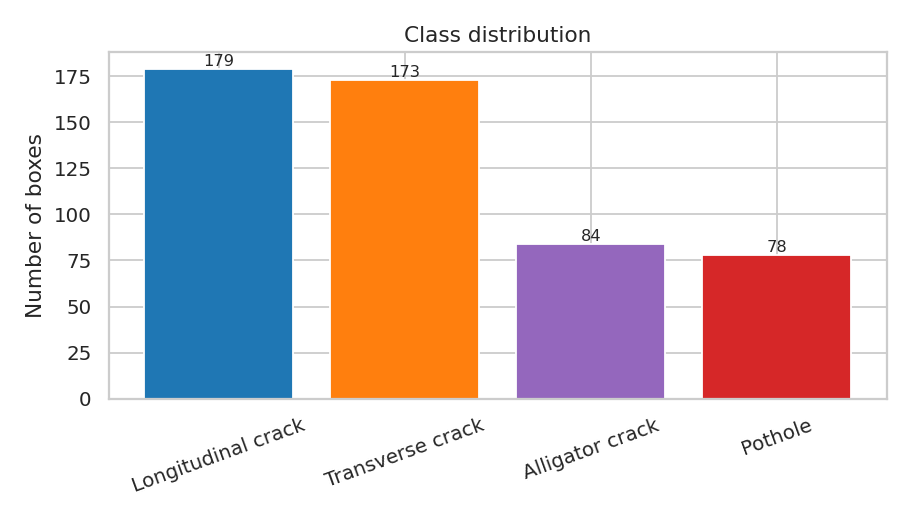

In [11]:
dist = data_prep.dataset_class_distribution(annotations)
display(pd.DataFrame({'code': list(config.YOLO_NAMES),
                      'name': [config.CLASS_NAMES[c] for c in config.YOLO_NAMES],
                      'boxes': [dist.get(c, 0) for c in config.YOLO_NAMES]}))
fig, ax = plt.subplots(figsize=(7, 4))
visualization.plot_class_distribution(dist, ax=ax)
fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_class_distribution.png', dpi=130); plt.show()

## 3 · How many defects per image, and how big are they?

Most road images contain only one or two annotated defects, and crack boxes
are often very elongated (high width-to-height ratio), both facts inform the
augmentation choices (heavy mosaic, modest scaling) and the severity geometry.

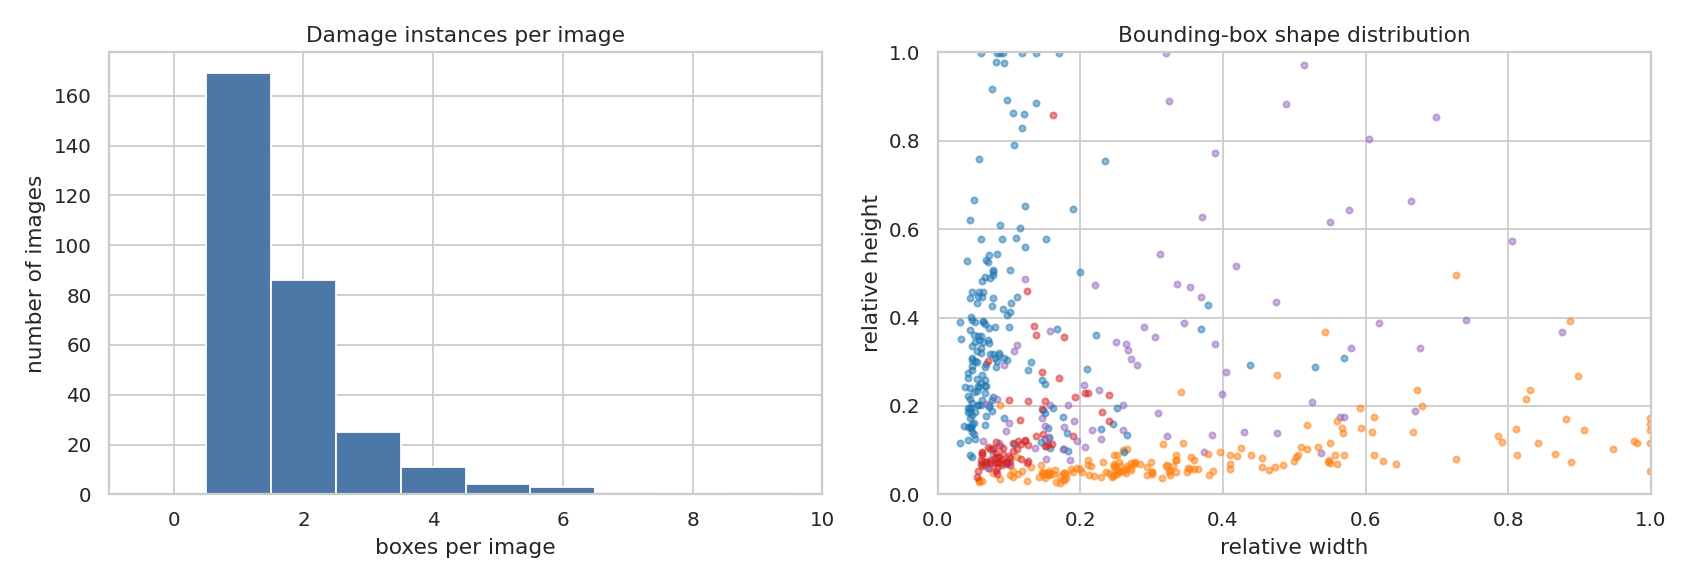

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
visualization.plot_boxes_per_image(annotations, ax=axes[0])
visualization.plot_bbox_size_distribution(annotations, ax=axes[1])
fig.tight_layout(); fig.savefig(FIG_DIR / 'eda_box_stats.png', dpi=130); plt.show()

## 4 · Sample images with ground-truth boxes

A quick visual sanity check that the annotations line up with the imagery and
that the four classes look as expected.

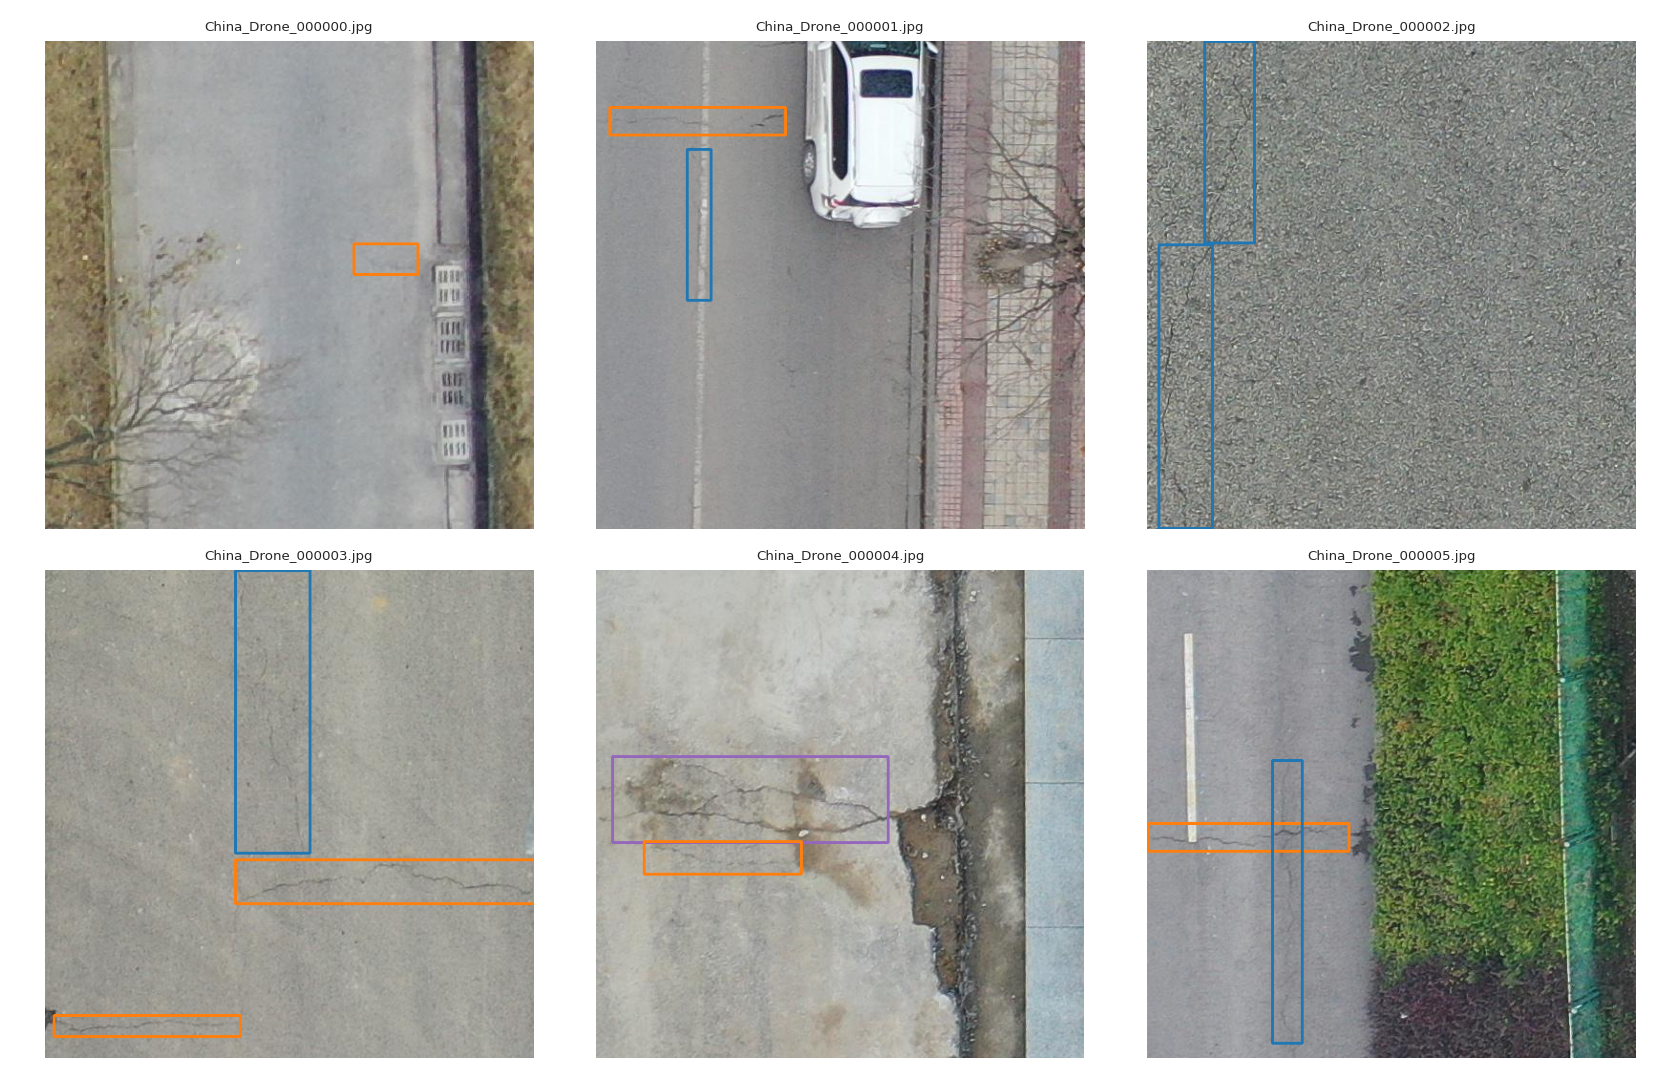

In [13]:
annotations_by_name = {a.filename: a for a in annotations}
sample_paths = sorted(IMAGES_DIR.glob('*.jpg'))[:6]
fig = visualization.make_gallery(sample_paths, annotations_by_name, n=6, cols=3)
fig.savefig(FIG_DIR / 'eda_sample_gallery.png', dpi=120); plt.show()

## 5 · Build the YOLO dataset (VOC → YOLO) and the stratified split

We convert every VOC box to a normalised YOLO line and deal images into
train/val/test so the **rarest class stays present in every split**, vital
with so few potholes. The split is seeded, so it is identical here and in the
training notebook.

In [14]:
# Working directory for the converted YOLO dataset.
# On Colab we build it on the fast local disk; the split is deterministic
# (seed=42) so every notebook reconstructs an identical train/val/test split.
YOLO_DIR = '/content/yolo_dataset' if IN_COLAB else os.path.join(PROJECT_DIR, 'outputs', 'yolo_dataset')
print('YOLO_DIR =', YOLO_DIR)

In [15]:
summary = data_prep.build_yolo_dataset(IMAGES_DIR, ANN_DIR, YOLO_DIR,
                                       ratios=config.SPLIT_RATIOS, seed=config.SPLIT_SEED)
print('Per-split image / box counts:')
display(pd.DataFrame(summary['per_split']).T)
print('\nPer-split class distribution (boxes):')
display(pd.DataFrame(summary['class_per_split']).fillna(0).astype(int).T[config.YOLO_NAMES])
print('\ndata.yaml written to:', Path(YOLO_DIR) / 'data.yaml')
print((Path(YOLO_DIR) / 'data.yaml').read_text())

split,images,boxes,D00,D10,D20,D40
train,210,361,134,113,60,54
val,60,105,29,43,16,17
test,30,48,16,17,8,7


YOLO dataset written to outputs/yolo_dataset with seed=42


**Interpretation.** The stratified split keeps all four classes present in
train, validation and test. The test split holds 30 images and 48 boxes,
including 7 potholes and 8 alligator-crack boxes, so the held-out metrics are
meaningful for every class and not just for the common ones. Because the split
is seeded (seed 42), the training and inference notebooks rebuild exactly the
same split, which is what makes the whole pipeline reproducible.

## 6. Key findings and modelling implications

The exploration quantifies the dataset; these measured facts guide the modelling choices:

- **Size and density.** 300 images, 514 defects, 1.71 per image, no background-only images. The dataset is small enough that transfer learning is essential.
- **Class imbalance.** Longitudinal 179, transverse 173, alligator 84, pothole 78. Linear cracks are about 68% of all boxes, so the evaluation reports per-class metrics and keeps every class in every split.
- **Geometry.** Many crack boxes are small and elongated, confirming a small-object detection problem and motivating the 512 px resolution plus mosaic strategy.
- **Reproducible split.** train 210 images / 361 boxes, val 60 / 105, test 30 / 48, with every class present in every split.

These EDA findings justify the downstream design: COCO transfer learning, comparison of several YOLO26 scales, and explicit attention to rare classes during evaluation.
